# Problem Description
**URL:**  
https://www.drivendata.org/competitions/66/flu-shot-learning/
**Challenge description:**  
This challenge uses survey data to predict whether individuals receive H1N1 or seasonal flu vaccines. The features include respondents’ social, economic, and demographic backgrounds; their opinions on risk of illness and vaccine effectiveness; and their behaviors toward mitigating transmission. There are both numerical and categorical variables (e.g., race, education, occupation).

**Datapoint definition:**  
Each datapoint is one survey respondent’s full record of demographics, opinions, and behaviors.

**Outcome variable:**  
Binary indicators for whether the respondent was vaccinated or unvaccinated against H1N1 and against seasonal flu.

# Dataset Description
- **Number of examples:** ~26,700  
- **Number of features:** 35  
- I do believe that we may need a feature reduction technique in a supervised ML approach, since there are considerably more examples compared to the features with both together making a incredibly huge dataset. However, overall, the data set has a moderate dataset compared to the size of the data points so, we may be amply sampling the region. 

**How the dataset is provided:**  
The data is provided on thier site and is divided into the following categories: 
- Submission Format
- Training set features.
- Labels for the training set.
- Test set features.

**Stated file size:**  
- The website only provides the link not how big the file is. 

# Data Gathering and processing;

**Downloading the data diretly from the website** 

The data was downloaded directly from the challenge site site:  

In [3]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gffutils
import pyfaidx

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn import svm
from sklearn.metrics import *

In [4]:
# Loading the Dataset as a Dataframe
import pandas as pd
df = pd.read_csv('training_set_features.csv')
df_t = pd.read_csv('test_set_features.csv') 
labels = pd.read_csv('training_set_labels.csv')



# merging the df and labels into one combined data set by matching to the common column and keeping those that match for both data frames
data = df.merge(labels, on='respondent_id', how='inner')
data_t = df_t.merge(labels, on='respondent_id', how='inner')
print(df.shape)
data.head()

(26707, 36)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


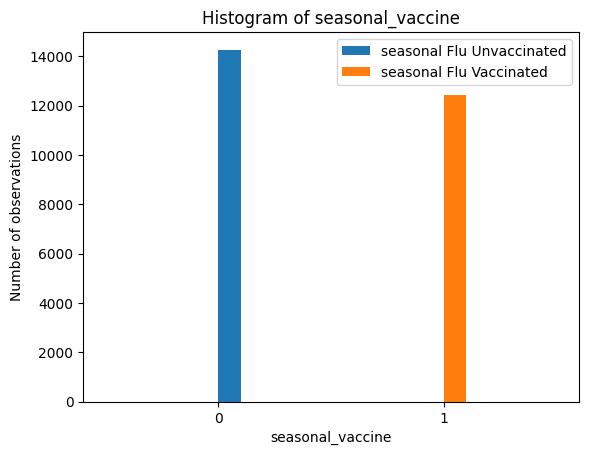

In [5]:
# Plotting a Histogram to show the class distribution of the patients sealsonal vaccine status

feature_name = "seasonal_vaccine" # Column Name for the outcome var
# subesting based on outcome: 
class_1_feat = data[data["seasonal_vaccine"] == 0][feature_name] 
class_2_feat = data[data["seasonal_vaccine"] == 1][feature_name]
class_1_name = "seasonal Flu Unvaccinated"
class_2_name = "seasonal Flu Vaccinated"

plt.hist(class_1_feat, label=class_1_name)
plt.hist(class_2_feat, label=class_2_name)

plt.legend(loc='upper right')
plt.title(f"Histogram of {feature_name}")
plt.xlabel(f"{feature_name}")
plt.ylabel("Number of observations")
plt.xticks([0,1])
plt.show()

## Preping the data to take care of missing value: 

In [6]:
# looking the number of NA values in the data set: 
df.isnull().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

In [7]:
# We can see that there are certain features that have really high number of missing values,
# Since we onle have ~27000 feature, I think dropping any columns that have more than 1000 missing values
# should be dropped, and for the others I will remove those rows. 

na_counts = df.isnull().sum()
cols_d = na_counts[ na_counts > 1000].index.tolist()

df2= df.drop(columns=cols_d)
org_dp = df2.shape[0]
df2


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,race,sex,hhs_geo_region,census_msa,household_adults,household_children
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,2.0,1.0,2.0,55 - 64 Years,White,Female,oxchjgsf,Non-MSA,0.0,0.0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,4.0,2.0,4.0,35 - 44 Years,White,Male,bhuqouqj,"MSA, Not Principle City",0.0,0.0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,1.0,2.0,18 - 34 Years,White,Male,qufhixun,"MSA, Not Principle City",2.0,0.0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,5.0,4.0,1.0,65+ Years,White,Female,lrircsnp,"MSA, Principle City",0.0,0.0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,3.0,1.0,4.0,45 - 54 Years,White,Female,qufhixun,"MSA, Not Principle City",1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,5.0,2.0,2.0,65+ Years,White,Female,qufhixun,Non-MSA,0.0,0.0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,5.0,1.0,1.0,18 - 34 Years,White,Male,lzgpxyit,"MSA, Principle City",1.0,0.0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,5.0,4.0,2.0,55 - 64 Years,White,Female,lzgpxyit,"MSA, Not Principle City",0.0,0.0
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,2.0,1.0,2.0,18 - 34 Years,Hispanic,Female,lrircsnp,Non-MSA,1.0,0.0


In [8]:
# now removing the rows with na 
df2= df2.dropna()
drop_dp = df2.shape[0]
print (f" {org_dp-drop_dp}, is the numeber for data points that were removed")


 1904, is the numeber for data points that were removed


In [9]:
# Now we can drop those same rows from the labels dataframe: 
labels2 = labels[labels['respondent_id'].isin(df2['respondent_id'])]


**We can see that the there is not a vast class difference for seasonal flu vaccinated individuals. We will now further analyse the data to look for categorical features and making them numerical.**

In [10]:
# Splitting the Dataframe for categorical features:
categorical = df2.select_dtypes(include=['object','category']).columns.tolist()
df2[categorical]

,age_group,race,sex,hhs_geo_region,census_msa
0,55 - 64 Years,White,Female,oxchjgsf,Non-MSA
1,35 - 44 Years,White,Male,bhuqouqj,"MSA, Not Principle City"
2,18 - 34 Years,White,Male,qufhixun,"MSA, Not Principle City"
3,65+ Years,White,Female,lrircsnp,"MSA, Principle City"
4,45 - 54 Years,White,Female,qufhixun,"MSA, Not Principle City"
...,...,...,...,...,...
26701,18 - 34 Years,White,Female,fpwskwrf,"MSA, Principle City"
26702,65+ Years,White,Female,qufhixun,Non-MSA
26703,18 - 34 Years,White,Male,lzgpxyit,"MSA, Principle City"
26704,55 - 64 Years,White,Female,lzgpxyit,"MSA, Not Principle City"


In [11]:
# We can see that there are 12 features which are categorical, lets see the categories for each: 
for col in categorical:
    cats = df2[col].dropna().unique()
    print(f"{col}:, {cats} ") 

age_group:, ['55 - 64 Years' '35 - 44 Years' '18 - 34 Years' '65+ Years'
 '45 - 54 Years'] 
race:, ['White' 'Black' 'Other or Multiple' 'Hispanic'] 
sex:, ['Female' 'Male'] 
hhs_geo_region:, ['oxchjgsf' 'bhuqouqj' 'qufhixun' 'lrircsnp' 'atmpeygn' 'lzgpxyit'
 'fpwskwrf' 'mlyzmhmf' 'dqpwygqj' 'kbazzjca'] 
census_msa:, ['Non-MSA' 'MSA, Not Principle  City' 'MSA, Principle City'] 


In [12]:
# making a dictionary for the categorical feturues:
cat_df ={}
for col in categorical:
    cats = df2[col].dropna().unique()
    cat_df[col]=cats
cat_df

{'age_group': array(['55 - 64 Years', '35 - 44 Years', '18 - 34 Years', '65+ Years',
        '45 - 54 Years'], dtype=object),
 'race': array(['White', 'Black', 'Other or Multiple', 'Hispanic'], dtype=object),
 'sex': array(['Female', 'Male'], dtype=object),
 'hhs_geo_region': array(['oxchjgsf', 'bhuqouqj', 'qufhixun', 'lrircsnp', 'atmpeygn',
        'lzgpxyit', 'fpwskwrf', 'mlyzmhmf', 'dqpwygqj', 'kbazzjca'],
       dtype=object),
 'census_msa': array(['Non-MSA', 'MSA, Not Principle  City', 'MSA, Principle City'],
       dtype=object)}

In [13]:
# now we will covert these categories to numbers by assigning them number in asscending order for thier respective order in the df above, using it a mapping index
df2["age_group"] = df2["age_group"].map({
    "55 - 64 Years": 0, "35 - 44 Years": 1, "18 - 34 Years": 2, "65+ Years": 3, "45 - 54 Years": 4
})

df2["race"] = df2["race"].map({
    "White": 0, "Black": 1, "Other or Multiple": 2, "Hispanic": 3
})

df2["sex"] = df2["sex"].map({
    "Female": 0, "Male": 1
})

df2["hhs_geo_region"] = df2["hhs_geo_region"].map({
    "oxchjgsf": 0, "bhuqouqj": 1, "qufhixun": 2, "lrircsnp": 3, "atmpeygn": 4,
    "lzgpxyit": 5, "fpwskwrf": 6, "mlyzmhmf": 7, "dqpwygqj": 8, "kbazzjca": 9
})

df2["census_msa"] = df2["census_msa"].map({
    "Non-MSA": 0, "MSA, Not Principle  City": 1, "MSA, Principle City": 2
})

/var/folders/k_/t5gl11yd5496_djwn7shkqrm0000gn/T/ipykernel_53554/263030195.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["age_group"] = df2["age_group"].map({
/var/folders/k_/t5gl11yd5496_djwn7shkqrm0000gn/T/ipykernel_53554/263030195.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["race"] = df2["race"].map({
/var/folders/k_/t5gl11yd5496_djwn7shkqrm0000gn/T/ipykernel_53554/263030195.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

# Splitting the data 

### Since the data provided to us has already been split in a test set and training set, I decide to train on the training set by considering it the crossvalidation set

In [36]:
# manually creating the class and dataframe sepration for the crossvalidation set 
df_crossval = df2.copy()
class_crossval = labels2["seasonal_vaccine"].copy()

# Copying the now crossvalidation dataframe and replacing the index
df_crossval.reset_index(inplace = True)
class_crossval = class_crossval.reset_index()




# Begining SVM Model Building

In [15]:
# Preparing data for crossvalidation: 
n_partitions = 5
skf = StratifiedKFold(n_splits = n_partitions)


# Split into crossvalidation sets (sets of indices in df_crossval and class_crossval)
#  and print out the resulting partition compositions for each partition as
y = class_crossval["seasonal_vaccine"]  # This line is needed for the np.bincount function to work
for train, test in skf.split(df_crossval, y):
    print(f"train : {np.bincount(y[train])} | test : {np.bincount(y[test])}")

train : [10548  9294] | test : [2638 2323]
train : [10549  9293] | test : [2637 2324]
train : [10549  9293] | test : [2637 2324]
train : [10549  9294] | test : [2637 2323]
train : [10549  9294] | test : [2637 2323]


In [16]:
# Applying SVM Classifier 
clf = svm.SVC(kernel='linear', C=1, random_state=42)  # define classifier
scores = cross_validate(clf, df_crossval, class_crossval["seasonal_vaccine"], cv=skf,
    scoring=('accuracy', 'precision'),
    return_train_score=True)

In [17]:
# Examine results
scores

# Nicer printing of specific performance metrics across partitions
scores_train_acc = scores["train_accuracy"]
print('%, '.join([str(round(100*x, 2)) for x in scores_train_acc]) + '%')

scores_train_acc = scores["test_accuracy"]
print('%, '.join([str(round(100*x, 2)) for x in scores_train_acc]) + '%')

72.94%, 72.76%, 73.12%, 73.37%, 73.26%
72.81%, 73.05%, 73.57%, 73.27%, 72.1%


In [18]:
# Prepare for final model training and evaluation
df_crossval = df_crossval.set_index("index") # remove explicit index column and reset indices to the original dataset indices
class_crossval = class_crossval.set_index("index") # remove explicit index column and reset indices to the original dataset indices

In [ ]:
clf_final = svm.SVC(kernel='linear', C=1, random_state=42)  # define classifier

final_model = clf_final.fit(df_crossval, class_crossval['seasonal_vaccine']) # train model


In [ ]:
pred_train = final_model.predict(df_crossval) # predict class labels for the training set
pred_test = final_model.predict(df_t) # predict class labels for the independent test set


In [ ]:
# Evaluate final model performance

accuracy_score(pred_train, class_crossval) # accuracy in training
accuracy_score(pred_test, class_test) # accuracy in testing

confusion_matrix(pred_train, class_crossval) # confusion matrix in training
confusion_matrix(pred_test, class_test) # confusion matrix in testing
